# Train Hierarchical BiLSTM + CRF (GPU Optimized)

Notebook nay huan luyen mo hinh Hierarchical BiLSTM + CRF tren du lieu da tien xu ly trong data/processed.

Toi uu cho GPU:
- Mixed Precision (AMP)
- pin_memory + num_workers + persistent_workers
- cuDNN benchmark
- gradient clipping
- early stopping + best checkpoint

In [1]:
# Neu thieu thu vien, bo comment dong duoi roi chay
# %pip install -q pytorch-crf TorchCRF scikit-learn seqeval

import json
import random
import importlib
from pathlib import Path
from dataclasses import dataclass

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pack_padded_sequence, pad_packed_sequence
from sklearn.metrics import classification_report, f1_score

CRF_BACKEND = None
CRF = None
for module_name, backend_name in [("torchcrf", "torchcrf"), ("TorchCRF", "TorchCRF")]:
    try:
        mod = importlib.import_module(module_name)
        CRF = getattr(mod, "CRF")
        CRF_BACKEND = backend_name
        break
    except Exception:
        continue

if CRF is None:
    raise ImportError(
        "Can not import CRF. Install one of: pytorch-crf or TorchCRF in active kernel."
    )

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

if torch.cuda.is_available():
    torch.backends.cudnn.benchmark = True

print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("CRF backend:", CRF_BACKEND)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Torch version: 2.11.0+cu130
CUDA available: True
CRF backend: TorchCRF
GPU: Quadro RTX 6000


In [2]:
def find_project_root_by_data_processed(start: Path) -> Path:
    start = start.resolve()
    for p in [start, *start.parents]:
        if (p / "data" / "processed").exists():
            return p
    raise FileNotFoundError(
        "Can not find data/processed from current working directory. "
        "Hay mo notebook trong project hoac sua thu cong duong dan trong Config."
    )


PROJECT_ROOT = find_project_root_by_data_processed(Path.cwd())


@dataclass
class Config:
    data_dir: Path = PROJECT_ROOT / "data" / "processed"
    model_dir: Path = PROJECT_ROOT / "models"

    train_file: str = "train.jsonl"
    dev_file: str = "dev.jsonl"
    test_file: str = "test.jsonl"
    vocab_file: str = "vocab.json"
    label2id_file: str = "label2id.json"

    embedding_dim: int = 200
    word_hidden_dim: int = 256
    sent_hidden_dim: int = 256
    dropout: float = 0.45

    batch_size: int = 64
    num_workers: int = 6

    epochs: int = 25
    lr: float = 3e-4
    weight_decay: float = 1e-2
    max_grad_norm: float = 1.0
    patience: int = 5

    use_amp: bool = True
    save_name: str = "best_hier_bilstm_crf_gpu.pth"


cfg = Config()
cfg.model_dir.mkdir(parents=True, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("PROJECT_ROOT:", PROJECT_ROOT)
print(cfg)
print("Device:", device)

PROJECT_ROOT: /home/nvidia
Config(data_dir=PosixPath('/home/nvidia/data/processed'), model_dir=PosixPath('/home/nvidia/models'), train_file='train.jsonl', dev_file='dev.jsonl', test_file='test.jsonl', vocab_file='vocab.json', label2id_file='label2id.json', embedding_dim=200, word_hidden_dim=256, sent_hidden_dim=256, dropout=0.45, batch_size=64, num_workers=6, epochs=25, lr=0.0003, weight_decay=0.01, max_grad_norm=1.0, patience=5, use_amp=True, save_name='best_hier_bilstm_crf_gpu.pth')
Device: cuda


In [3]:
def read_json(path: Path):
    with path.open("r", encoding="utf-8") as f:
        return json.load(f)


def read_jsonl(path: Path):
    rows = []
    with path.open("r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if line:
                rows.append(json.loads(line))
    return rows


label2id = read_json(cfg.data_dir / cfg.label2id_file)
id2label = {v: k for k, v in label2id.items()}
vocab = read_json(cfg.data_dir / cfg.vocab_file)

print("Num labels:", len(label2id))
print("Num vocab:", len(vocab))
print("Labels:", label2id)

Num labels: 5
Num vocab: 34576
Labels: {'BACKGROUND': 0, 'CONCLUSIONS': 1, 'METHODS': 2, 'OBJECTIVE': 3, 'RESULTS': 4}


In [4]:
class AbstractDataset(Dataset):
    def __init__(self, rows):
        self.rows = rows

    def __len__(self):
        return len(self.rows)

    def __getitem__(self, idx):
        r = self.rows[idx]
        return {
            "input_ids": torch.tensor(r["input_ids"], dtype=torch.long),
            "word_mask": torch.tensor(r["word_mask"], dtype=torch.bool),
            "sentence_mask": torch.tensor(r["sentence_mask"], dtype=torch.bool),
            "label_ids": torch.tensor(r["label_ids"], dtype=torch.long),
        }


def collate_fn(batch):
    return {
        "input_ids": torch.stack([x["input_ids"] for x in batch], dim=0),
        "word_mask": torch.stack([x["word_mask"] for x in batch], dim=0),
        "sentence_mask": torch.stack([x["sentence_mask"] for x in batch], dim=0),
        "label_ids": torch.stack([x["label_ids"] for x in batch], dim=0),
    }


train_rows = read_jsonl(cfg.data_dir / cfg.train_file)
dev_rows = read_jsonl(cfg.data_dir / cfg.dev_file)
test_rows = read_jsonl(cfg.data_dir / cfg.test_file)

train_ds = AbstractDataset(train_rows)
dev_ds = AbstractDataset(dev_rows)
test_ds = AbstractDataset(test_rows)

loader_kwargs = dict(
    batch_size=cfg.batch_size,
    num_workers=cfg.num_workers,
    pin_memory=torch.cuda.is_available(),
    collate_fn=collate_fn,
)

if cfg.num_workers > 0:
    loader_kwargs["persistent_workers"] = True

train_loader = DataLoader(train_ds, shuffle=True, **loader_kwargs)
dev_loader = DataLoader(dev_ds, shuffle=False, **loader_kwargs)
test_loader = DataLoader(test_ds, shuffle=False, **loader_kwargs)

print("train/dev/test:", len(train_ds), len(dev_ds), len(test_ds))

train/dev/test: 15000 2500 2500


In [5]:
class HierarchicalBiLSTMCRF(nn.Module):
    def __init__(
        self,
        vocab_size,
        num_labels,
        embedding_dim=200,
        word_hidden_dim=256,
        sent_hidden_dim=256,
        dropout=0.45,
        pad_idx=0,
    ):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=pad_idx)
        self.word_encoder = nn.LSTM(
            input_size=embedding_dim,
            hidden_size=word_hidden_dim,
            batch_first=True,
            bidirectional=True,
        )

        self.sent_encoder = nn.LSTM(
            input_size=word_hidden_dim * 2,
            hidden_size=sent_hidden_dim,
            batch_first=True,
            bidirectional=True,
        )

        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(sent_hidden_dim * 2, num_labels)

        # Make CRF init robust across different CRF packages/APIs.
        self.crf_backend = "unknown"
        try:
            self.crf = CRF(num_labels, batch_first=True)
            self.crf_backend = "torchcrf-like"
        except TypeError:
            try:
                self.crf = CRF(
                    num_labels, pad_idx=None, use_gpu=torch.cuda.is_available()
                )
                self.crf_backend = "TorchCRF-like"
            except TypeError:
                self.crf = CRF(num_labels)
                self.crf_backend = "generic-crf"

    def _encode_words(self, input_ids, word_mask):
        # input_ids: [B, S, W]
        bsz, max_sents, max_words = input_ids.shape

        flat_ids = input_ids.view(-1, max_words)
        flat_mask = word_mask.view(-1, max_words)
        lengths = flat_mask.sum(dim=1)

        sent_repr = torch.zeros(
            flat_ids.size(0),
            self.word_encoder.hidden_size * 2,
            device=input_ids.device,
            dtype=self.embedding.weight.dtype,
        )

        valid = lengths > 0
        if valid.any():
            ids_valid = flat_ids[valid]
            len_valid = lengths[valid].cpu()

            emb = self.embedding(ids_valid)
            packed = pack_padded_sequence(
                emb, len_valid, batch_first=True, enforce_sorted=False
            )
            _, (h_n, _) = self.word_encoder(packed)

            # h_n: [2, n_valid, H] vi 1 layer + bidirectional
            sent_valid = torch.cat([h_n[-2], h_n[-1]], dim=-1)
            # Under AMP, sent_valid can be float16 while sent_repr is float32.
            sent_repr[valid] = sent_valid.to(sent_repr.dtype)

        sent_repr = sent_repr.view(bsz, max_sents, -1)
        return sent_repr

    def _emissions(self, input_ids, word_mask, sentence_mask):
        sent_repr = self._encode_words(input_ids, word_mask)
        sent_repr = self.dropout(sent_repr)

        sent_lengths = sentence_mask.sum(dim=1).cpu()
        packed = pack_padded_sequence(
            sent_repr, sent_lengths, batch_first=True, enforce_sorted=False
        )
        packed_out, _ = self.sent_encoder(packed)
        sent_out, _ = pad_packed_sequence(
            packed_out, batch_first=True, total_length=sentence_mask.size(1)
        )

        sent_out = self.dropout(sent_out)
        emissions = self.classifier(sent_out)
        return emissions

    def loss(self, input_ids, word_mask, sentence_mask, labels):
        emissions = self._emissions(input_ids, word_mask, sentence_mask)

        if hasattr(self.crf, "decode"):
            # torchcrf-like
            try:
                nll = -self.crf(emissions, labels, mask=sentence_mask, reduction="mean")
            except TypeError:
                nll = -self.crf(emissions, labels, mask=sentence_mask)
                if isinstance(nll, torch.Tensor) and nll.ndim > 0:
                    nll = nll.mean()
        else:
            # TorchCRF-like: replace ignored labels at padded positions to avoid invalid indexing.
            safe_labels = labels.clone()
            safe_labels = safe_labels.long()
            safe_labels[~sentence_mask] = 0
            llh = self.crf(emissions, safe_labels, sentence_mask)
            nll = -llh.mean()

        return nll

    @torch.no_grad()
    def decode(self, input_ids, word_mask, sentence_mask):
        emissions = self._emissions(input_ids, word_mask, sentence_mask)

        if hasattr(self.crf, "decode"):
            try:
                return self.crf.decode(emissions, mask=sentence_mask)
            except TypeError:
                return self.crf.decode(emissions, sentence_mask)

        if hasattr(self.crf, "viterbi_decode"):
            return self.crf.viterbi_decode(emissions, sentence_mask)

        raise RuntimeError("CRF implementation does not provide a decode method")

In [6]:
model = HierarchicalBiLSTMCRF(
    vocab_size=len(vocab),
    num_labels=len(label2id),
    embedding_dim=cfg.embedding_dim,
    word_hidden_dim=cfg.word_hidden_dim,
    sent_hidden_dim=cfg.sent_hidden_dim,
    dropout=cfg.dropout,
).to(device)

optimizer = torch.optim.AdamW(
    model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay
)
try:
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="max", factor=0.5, patience=1, verbose=True
    )
except TypeError:
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="max", factor=0.5, patience=1
    )
scaler = torch.amp.GradScaler("cuda", enabled=(cfg.use_amp and device.type == "cuda"))

num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print("Trainable params:", f"{num_params:,}")

Trainable params: 9,432,744


In [7]:
def move_batch_to_device(batch, device):
    return {k: v.to(device, non_blocking=True) for k, v in batch.items()}


def flatten_labels_for_metric(y_true_tensor, y_pred_lists, mask_tensor):
    y_true_all = []
    y_pred_all = []

    y_true_np = y_true_tensor.detach().cpu().numpy()
    mask_np = mask_tensor.detach().cpu().numpy()

    for i in range(len(y_pred_lists)):
        valid_len = int(mask_np[i].sum())
        true_seq = y_true_np[i][:valid_len].tolist()
        pred_seq = y_pred_lists[i][:valid_len]

        y_true_all.extend(true_seq)
        y_pred_all.extend(pred_seq)

    return y_true_all, y_pred_all


@torch.no_grad()
def evaluate(model, loader, device):
    model.eval()
    losses = []
    all_true = []
    all_pred = []

    for batch in loader:
        batch = move_batch_to_device(batch, device)

        loss = model.loss(
            batch["input_ids"],
            batch["word_mask"],
            batch["sentence_mask"],
            batch["label_ids"],
        )
        losses.append(loss.item())

        pred = model.decode(
            batch["input_ids"], batch["word_mask"], batch["sentence_mask"]
        )

        y_true, y_pred = flatten_labels_for_metric(
            batch["label_ids"], pred, batch["sentence_mask"]
        )
        all_true.extend(y_true)
        all_pred.extend(y_pred)

    macro_f1 = f1_score(all_true, all_pred, average="macro")
    weighted_f1 = f1_score(all_true, all_pred, average="weighted")

    return {
        "loss": float(np.mean(losses)),
        "macro_f1": macro_f1,
        "weighted_f1": weighted_f1,
        "y_true": all_true,
        "y_pred": all_pred,
    }

In [8]:
history = []
best_dev_f1 = -1.0
best_epoch = -1
wait = 0
best_path = cfg.model_dir / cfg.save_name

for epoch in range(1, cfg.epochs + 1):
    model.train()
    train_losses = []

    for batch in train_loader:
        batch = move_batch_to_device(batch, device)
        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast(
            "cuda", enabled=(cfg.use_amp and device.type == "cuda")
        ):
            loss = model.loss(
                batch["input_ids"],
                batch["word_mask"],
                batch["sentence_mask"],
                batch["label_ids"],
            )

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), cfg.max_grad_norm)
        scaler.step(optimizer)
        scaler.update()

        train_losses.append(loss.item())

    dev_metrics = evaluate(model, dev_loader, device)
    train_loss = float(np.mean(train_losses))

    scheduler.step(dev_metrics["macro_f1"])

    history.append(
        {
            "epoch": epoch,
            "train_loss": train_loss,
            "dev_loss": dev_metrics["loss"],
            "dev_macro_f1": dev_metrics["macro_f1"],
            "dev_weighted_f1": dev_metrics["weighted_f1"],
        }
    )

    print(
        f"Epoch {epoch:02d} | train_loss={train_loss:.4f} | dev_loss={dev_metrics['loss']:.4f} | "
        f"dev_macro_f1={dev_metrics['macro_f1']:.4f} | dev_weighted_f1={dev_metrics['weighted_f1']:.4f}"
    )

    if dev_metrics["macro_f1"] > best_dev_f1:
        best_dev_f1 = dev_metrics["macro_f1"]
        best_epoch = epoch
        wait = 0

        torch.save(
            {
                "model_state_dict": model.state_dict(),
                "config": cfg.__dict__,
                "label2id": label2id,
                "best_dev_macro_f1": best_dev_f1,
                "epoch": best_epoch,
            },
            best_path,
        )
    else:
        wait += 1

    if wait >= cfg.patience:
        print(f"Early stopping at epoch {epoch}. Best epoch: {best_epoch}")
        break

print("Best dev macro F1:", round(best_dev_f1, 4), "| epoch:", best_epoch)
print("Saved best model to:", best_path)

Epoch 01 | train_loss=6.3750 | dev_loss=3.5006 | dev_macro_f1=0.8307 | dev_weighted_f1=0.8823
Epoch 02 | train_loss=3.3347 | dev_loss=2.9226 | dev_macro_f1=0.8428 | dev_weighted_f1=0.8974
Epoch 03 | train_loss=2.8246 | dev_loss=2.6781 | dev_macro_f1=0.8552 | dev_weighted_f1=0.9058
Epoch 04 | train_loss=2.4903 | dev_loss=2.5035 | dev_macro_f1=0.8557 | dev_weighted_f1=0.9074
Epoch 05 | train_loss=2.2394 | dev_loss=2.4631 | dev_macro_f1=0.8601 | dev_weighted_f1=0.9101
Epoch 06 | train_loss=2.0215 | dev_loss=2.3297 | dev_macro_f1=0.8571 | dev_weighted_f1=0.9108
Epoch 07 | train_loss=1.8036 | dev_loss=2.4095 | dev_macro_f1=0.8572 | dev_weighted_f1=0.9087
Epoch 08 | train_loss=1.5431 | dev_loss=2.3534 | dev_macro_f1=0.8619 | dev_weighted_f1=0.9128
Epoch 09 | train_loss=1.4043 | dev_loss=2.4208 | dev_macro_f1=0.8623 | dev_weighted_f1=0.9122
Epoch 10 | train_loss=1.2978 | dev_loss=2.5483 | dev_macro_f1=0.8631 | dev_weighted_f1=0.9123
Epoch 11 | train_loss=1.1877 | dev_loss=2.6328 | dev_macro_f

,epoch,train_loss,dev_loss,dev_macro_f1,dev_weighted_f1
10,11,1.187674,2.632770,0.862683,0.911310
11,12,1.094653,2.606470,0.861117,0.910888
12,13,0.964564,2.771776,0.860333,0.910841
13,14,0.904217,2.845392,0.858538,0.908571
14,15,0.838880,2.915813,0.859056,0.909122


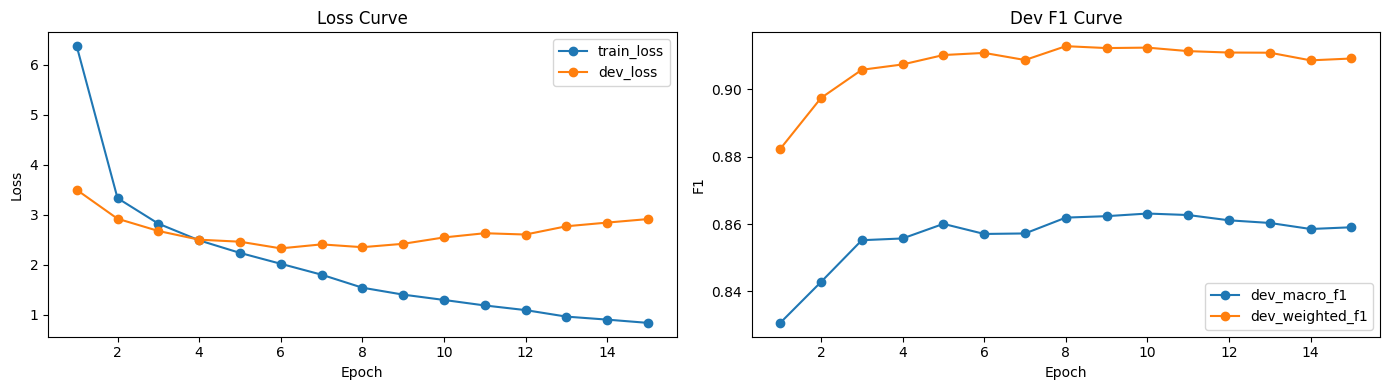

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

hist_df = pd.DataFrame(history)
display(hist_df.tail())

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(hist_df["epoch"], hist_df["train_loss"], marker="o", label="train_loss")
axes[0].plot(hist_df["epoch"], hist_df["dev_loss"], marker="o", label="dev_loss")
axes[0].set_title("Loss Curve")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()

axes[1].plot(
    hist_df["epoch"], hist_df["dev_macro_f1"], marker="o", label="dev_macro_f1"
)
axes[1].plot(
    hist_df["epoch"], hist_df["dev_weighted_f1"], marker="o", label="dev_weighted_f1"
)
axes[1].set_title("Dev F1 Curve")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("F1")
axes[1].legend()

plt.tight_layout()
plt.show()

In [11]:
# Load checkpoint robustly across PyTorch versions (2.6+ defaults weights_only=True).
import pathlib

try:
    checkpoint = torch.load(best_path, map_location=device, weights_only=False)
except TypeError:
    # Older PyTorch without weights_only argument.
    checkpoint = torch.load(best_path, map_location=device)
except Exception:
    # Optional allowlist fallback for environments enforcing weights_only behavior.
    with torch.serialization.safe_globals([pathlib.PosixPath, pathlib.WindowsPath]):
        checkpoint = torch.load(best_path, map_location=device)

model.load_state_dict(checkpoint["model_state_dict"])

test_metrics = evaluate(model, test_loader, device)
print("Test loss:", round(test_metrics["loss"], 4))
print("Test macro F1:", round(test_metrics["macro_f1"], 4))
print("Test weighted F1:", round(test_metrics["weighted_f1"], 4))

target_names = [id2label[i] for i in range(len(id2label))]
print("\nClassification report (test):")
print(
    classification_report(
        test_metrics["y_true"],
        test_metrics["y_pred"],
        target_names=target_names,
        digits=4,
    )
)

Test loss: 2.8694
Test macro F1: 0.8554
Test weighted F1: 0.9049

Classification report (test):
              precision    recall  f1-score   support

  BACKGROUND     0.7552    0.8212    0.7868      3568
 CONCLUSIONS     0.9608    0.9256    0.9429      4477
     METHODS     0.9385    0.9630    0.9506      9894
   OBJECTIVE     0.7237    0.5928    0.6517      2333
     RESULTS     0.9444    0.9459    0.9452      9673

    accuracy                         0.9062     29945
   macro avg     0.8645    0.8497    0.8554     29945
weighted avg     0.9052    0.9062    0.9049     29945



## GPU Tuning Tips
- Tang batch_size len khi VRAM du (vd 96, 128).
- Tang num_workers neu CPU manh va o dia nhanh.
- Thu embedding_dim=300 va hidden_dim=384 neu GPU du lon.
- Neu train lau, bat gradient accumulation theo buoc nho de gia lap batch lon.
- Neu can toi uu tiep, su dung torch.compile (PyTorch 2.x) tren may GPU moi.